In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import SGDRegressor

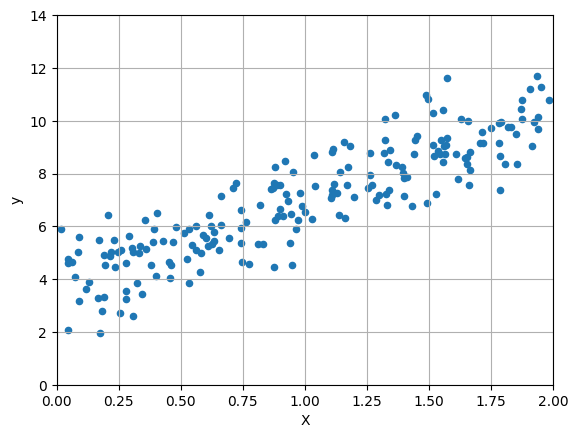

In [ ]:
rng = np.random.default_rng(seed= 42)
m = 200 # number of instances / records

X = 2 * rng.random((m, 1)) # column vector
y = 4 + 3 * X + rng.standard_normal((m, 1)) # column vector ( y = 4+3X)

pd.concat([pd.DataFrame(X, columns = ["X"]), pd.DataFrame(y, columns = ["y"])], axis= 1).plot(kind= "scatter", x = "X", y = "y", grid= True)
plt.axis([0,2,0,14])
plt.show()


In [79]:
x_b = add_dummy_feature(X)

In [80]:
# eta = 0.1
n_epochs = 50
t0, t1 = 5, 50
m = len(x_b)

In [81]:
def learning_schedule(t):
    return t0 / (t + t1)

In [86]:
rng = np.random.default_rng(seed = 42)
teta = np.random.standard_normal((2,1)) # randomly initialized model parameter
theta_path = [teta.copy()] 

In [87]:
for epoch in range(n_epochs):
    pindex = rng.permutation(m)
    for iteration in range(m):
        random_index = pindex[iteration]
        xi = x_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = xi.T @ (xi @ teta - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        teta = teta - eta * gradients
        theta_path.append(teta.copy())   # <-- record this step
        
theta_path = np.array(theta_path)  
teta

array([[3.66533747],
       [3.3521741 ]])

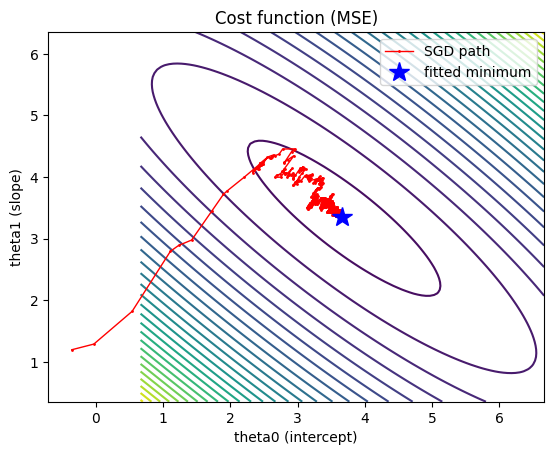

In [88]:
theta0_range = np.linspace(teta[0] - 3, teta[0] + 3, 100)
theta1_range = np.linspace(teta[1] - 3, teta[1] + 3, 100)

T0, T1 = np.meshgrid(theta0_range, theta1_range)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_ij = np.array([[T0[i, j]], [T1[i, j]]])
        preds = x_b @ theta_ij
        cost[i, j] = np.mean((preds - y) ** 2)

plt.contour(T0, T1, cost, levels=30, cmap='viridis')
plt.plot(theta_path[:, 0], theta_path[:, 1], 'r.-', linewidth=1, markersize=2, label='SGD path')
plt.plot(teta[0], teta[1], 'b*', markersize=15, label='fitted minimum')
plt.xlabel('theta0 (intercept)')
plt.ylabel('theta1 (slope)')
plt.title('Cost function (MSE)')
plt.legend()
plt.show()

In [102]:
sdg_reg = SGDRegressor(max_iter= 1000, tol= 1e-5, penalty= None, eta0= 0.01,
                       n_iter_no_change= 100, random_state= 42)
sdg_reg.fit(X, y.ravel())

sdg_reg.score(X, y.ravel())

sdg_reg.intercept_, sdg_reg.coef_

(array([3.68899733]), array([3.33054574]))

In [103]:
print(y.shape)
print(y.ravel().shape)

(200, 1)
(200,)
